<a href="https://colab.research.google.com/github/satyam-singh9828/3rd-year-projects-/blob/main/Image_enhancement_spatial_domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving apple.jpg to apple.jpg


/tmp/ipython-input-348794869.py:50: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(ch))
/tmp/ipython-input-348794869.py:50: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(ch))
/tmp/ipython-input-348794869.py:51: RuntimeWarning: divide by zero encountered in log
  return np.array(c * np.log(1 + ch), dtype=np.uint8)
/tmp/ipython-input-348794869.py:51: RuntimeWarning: invalid value encountered in multiply
  return np.array(c * np.log(1 + ch), dtype=np.uint8)
/tmp/ipython-input-348794869.py:51: RuntimeWarning: invalid value encountered in cast
  return np.array(c * np.log(1 + ch), dtype=np.uint8)


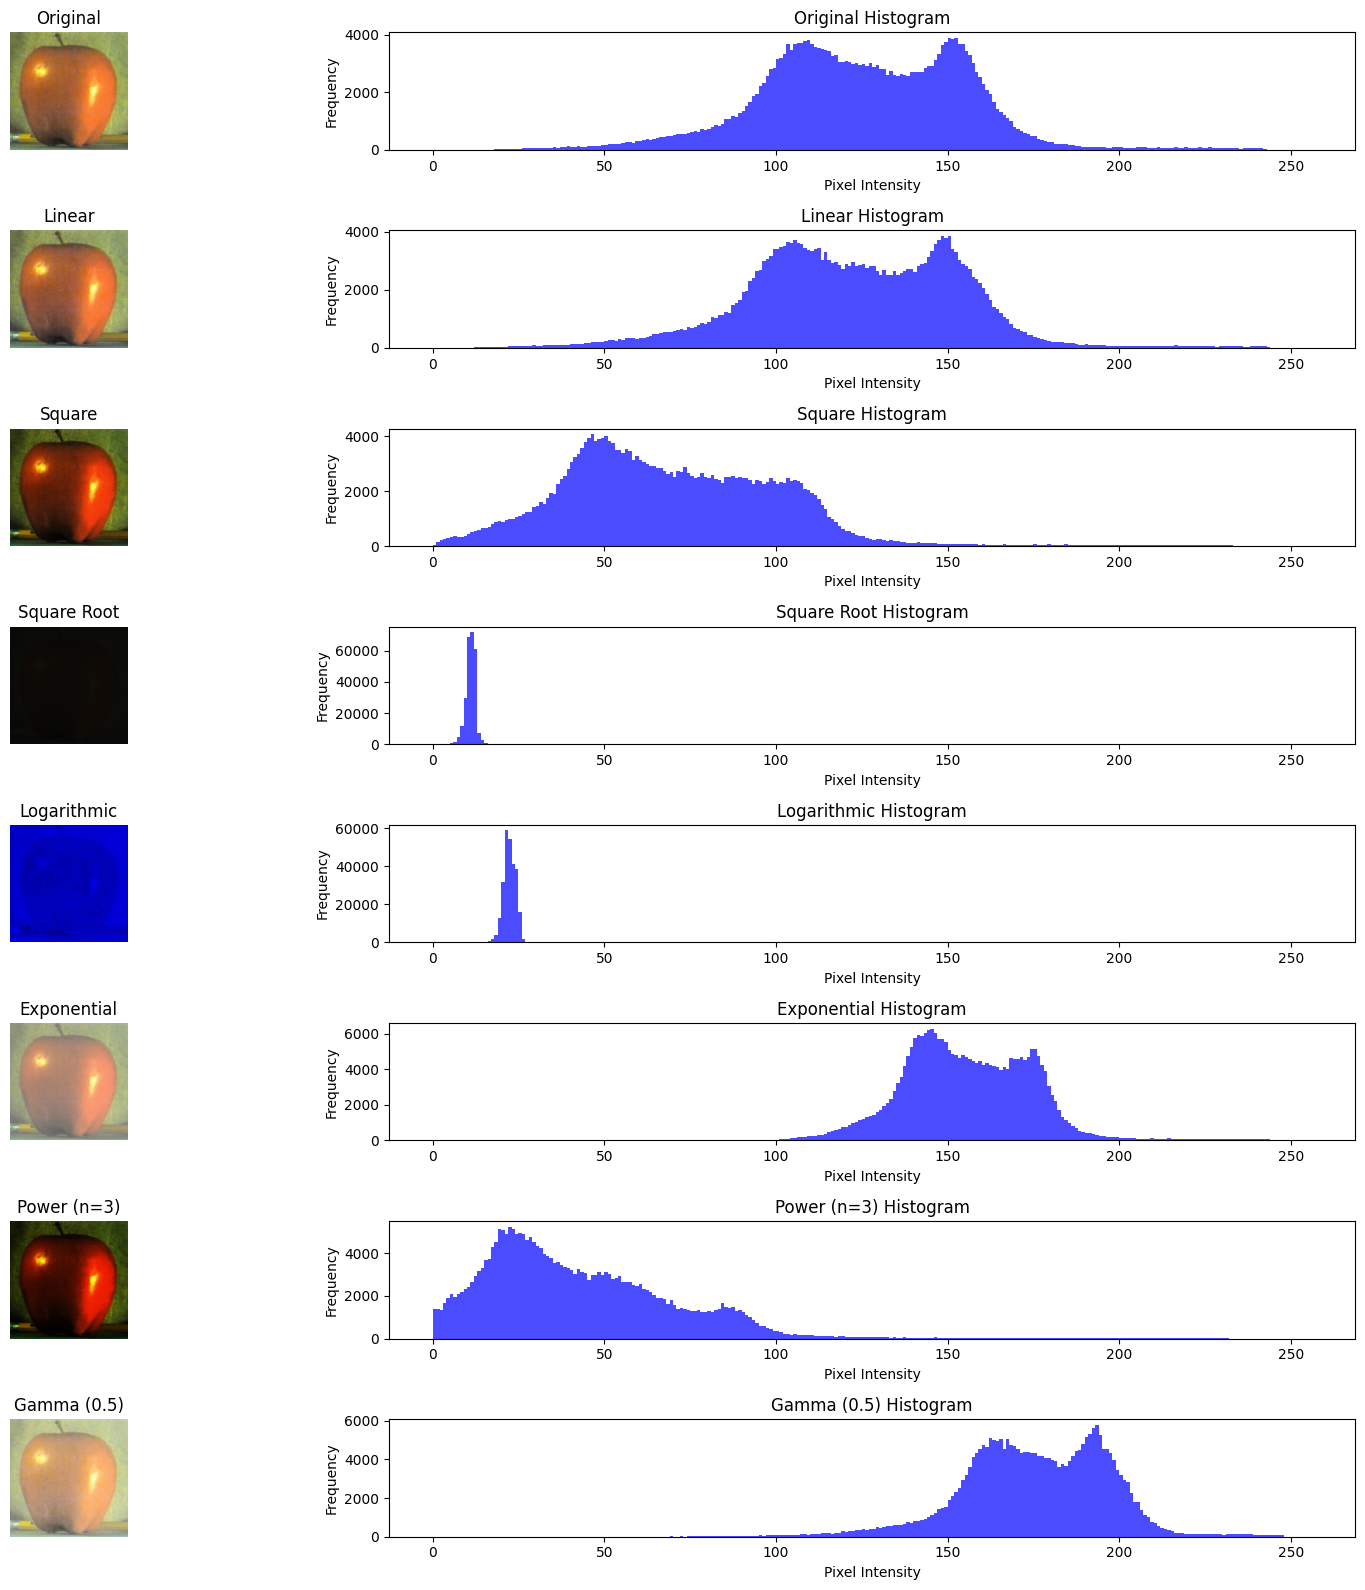

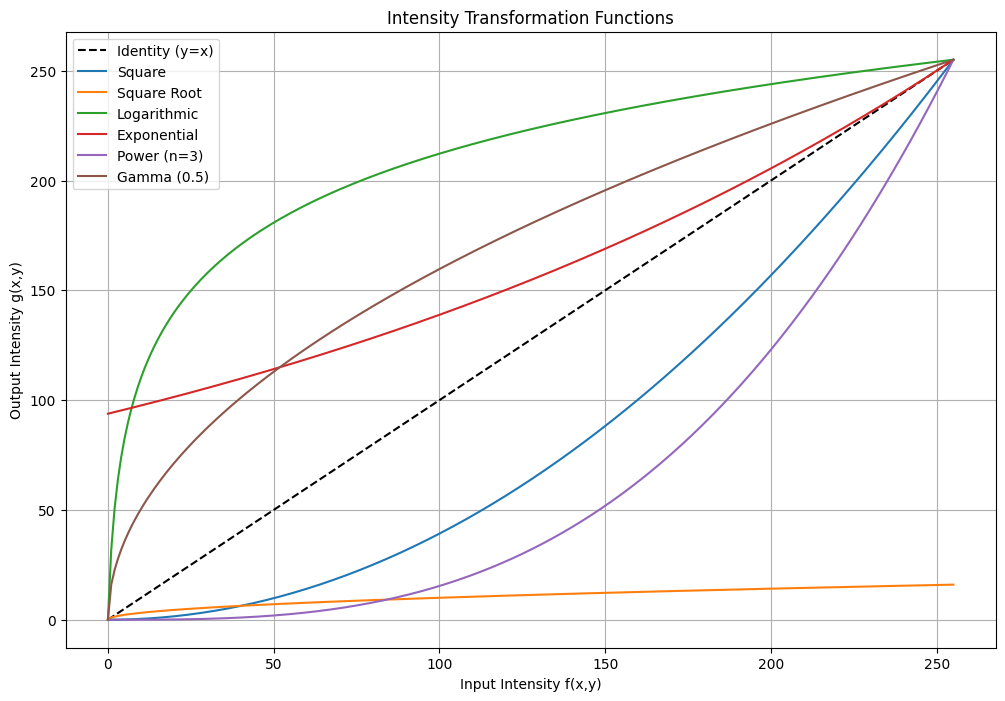

In [2]:
# Image Enhancement with Transfer Curves + Histograms
# Works in Google Colab

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------
# Upload an image
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Read color image (BGR → RGB)
img = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ------------------------------
# Helper: apply per channel
def apply_per_channel(img, func):
    channels = cv2.split(img)
    transformed = [func(ch) for ch in channels]
    return cv2.merge(transformed)

# Helper: show histogram of grayscale image
def plot_histogram(image, title):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    plt.hist(gray.ravel(), bins=256, range=(0,256), color='blue', alpha=0.7)
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

# ------------------------------
# Point Transformation Functions with textbook formulas

# 1. Linear (Contrast Stretching)
def linear(ch):
    return cv2.normalize(ch, None, 0, 255, cv2.NORM_MINMAX)

# 2. Square: g(x,y) = (f/255)^2 * 255
def square(ch):
    return np.array(np.power(ch/255.0, 2) * 255, dtype=np.uint8)

# 3. Square Root: g(x,y) = sqrt(255 * (f/255))
def sqrt_func(ch):
    return np.array(np.sqrt(255 * (ch/255.0)), dtype=np.uint8)

# 4. Logarithmic: g(x,y) = c*log(1+f)
def log_func(ch):
    c = 255 / np.log(1 + np.max(ch))
    return np.array(c * np.log(1 + ch), dtype=np.uint8)

# 5. Exponential: g(x,y) = (exp(f/255)/exp(1))*255
def exp_func(ch):
    return np.array(np.exp(ch/255.0) / np.exp(1) * 255, dtype=np.uint8)

# 6. Power Law: g(x,y) = (f/255)^n * 255
def power_func(ch, n=3):
    return np.array(np.power(ch/255.0, n) * 255, dtype=np.uint8)

# 7. Gamma Correction: g(x,y) = (f/255)^γ * 255
def gamma_func(ch, gamma=0.5):
    return np.array(np.power(ch/255.0, gamma) * 255, dtype=np.uint8)

# ------------------------------
# Apply transformations
linear_img = apply_per_channel(img_rgb, linear)
square_img = apply_per_channel(img_rgb, square)
sqrt_img = apply_per_channel(img_rgb, sqrt_func)
log_img = apply_per_channel(img_rgb, log_func)
exp_img = apply_per_channel(img_rgb, exp_func)
power_img = apply_per_channel(img_rgb, lambda ch: power_func(ch, n=3))
gamma_img = apply_per_channel(img_rgb, lambda ch: gamma_func(ch, gamma=0.5))

images = [img_rgb, linear_img, square_img, sqrt_img, log_img, exp_img, power_img, gamma_img]
titles = ["Original", "Linear", "Square", "Square Root", "Logarithmic", "Exponential", "Power (n=3)", "Gamma (0.5)"]

# ------------------------------
# Show images + histograms
plt.figure(figsize=(18, 16))
for i in range(len(images)):
    plt.subplot(len(images), 2, 2*i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(len(images), 2, 2*i+2)
    plot_histogram(images[i], f"{titles[i]} Histogram")
plt.tight_layout()
plt.show()

# ------------------------------
# Plot Intensity Transfer Functions
x = np.arange(0, 256)

y_square = (x/255.0)**2 * 255
y_sqrt   = np.sqrt(255*(x/255.0))
c = 255 / np.log(1+255)
y_log    = c * np.log(1 + x)
y_exp    = np.exp(x/255.0)/np.exp(1) * 255
y_power  = (x/255.0)**3 * 255
y_gamma  = (x/255.0)**0.5 * 255   # gamma=0.5

plt.figure(figsize=(12,8))
plt.plot(x, x, 'k--', label="Identity (y=x)")
plt.plot(x, y_square, label="Square")
plt.plot(x, y_sqrt, label="Square Root")
plt.plot(x, y_log, label="Logarithmic")
plt.plot(x, y_exp, label="Exponential")
plt.plot(x, y_power, label="Power (n=3)")
plt.plot(x, y_gamma, label="Gamma (0.5)")
plt.xlabel("Input Intensity f(x,y)")
plt.ylabel("Output Intensity g(x,y)")
plt.title("Intensity Transformation Functions")
plt.legend()
plt.grid(True)
plt.show()
